# Ejercicio 3 Practico 2 Ciencia de Datos

#### 3.a)

In [10]:
from wget import download
from os import path
import pandas as pd
import sweetviz as sv
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [11]:
# i) Descargar el archivo
if not path.exists("catalogo_streaming_argentina_2024.xlsx"):
    download("https://ignaciorlando.github.io/datasets/data-science/catalogo_streaming_argentina_2024.xlsx")
else:
    print("El archivo ya existe.")

El archivo ya existe.


In [17]:
# ii) Leer el archivo
catalogo = pd.read_excel("catalogo_streaming_argentina_2024.xlsx")

# iii) Cabecera
print(catalogo.columns)

Feature: title                               |▊         | [  8%]   02:26 -> (29:22 left)


Index(['title', 'platform', 'type', 'imdbVotes', 'imdbScore', 'tmdbPopularity',
       'tmdbScore', 'runtime', 'genres', 'director', 'year_range', 'url'],
      dtype='str')


In [13]:
# iv) Primeros 5 registros
catalogo.head()

,title,platform,type,imdbVotes,imdbScore,tmdbPopularity,tmdbScore,runtime,genres,director,year_range,url
0,Cadena perpetua,Max,MOVIE,2906253.0,9.3,159.594,8.705,142,"Drama, Crimen",Frank Darabont,1900_2002,https://play.max.com/movie/9b4dacba-2f80-4272-...
1,El caballero oscuro,Max,MOVIE,2893241.0,9.0,111.674,8.516,152,"Misterio & Suspense, Drama, Acción & Aventura,...",Christopher Nolan,2003_2010,https://play.max.com/movie/52217243-a137-45d6-...
2,Origen,Max,MOVIE,2570263.0,8.8,139.644,8.369,148,"Ciencia ficción, Acción & Aventura, Misterio &...",Christopher Nolan,2003_2010,https://play.max.com/movie/14552c93-d318-4563-...
3,El club de la lucha,Disney Plus,MOVIE,2345071.0,8.8,108.297,8.400,139,Drama,David Fincher,1998_2004,https://disneyplus.bn5x.net/c/1206980/705874/9...
4,El club de la lucha,Netflix,MOVIE,2345071.0,8.8,108.297,8.400,139,Drama,David Fincher,1995_2005,http://www.netflix.com/title/26004747


In [14]:
# v) Resumen estadístico
catalogo.describe(include="all")

,title,platform,type,imdbVotes,imdbScore,tmdbPopularity,tmdbScore,runtime,genres,director,year_range,url
count,19817,19817,19817,1.785400e+04,17927.000000,19538.000000,18954.000000,19817.000000,19665,14626,19817.0,19817
unique,18008,6,2,NaN,NaN,NaN,NaN,NaN,4189,8812,27.0,19062
top,Perdida,Netflix,MOVIE,NaN,NaN,NaN,NaN,NaN,Documental,Steven Spielberg,2022.0,http://www.netflix.com/title/81665878
freq,5,7109,14060,NaN,NaN,NaN,NaN,NaN,1277,27,1697.0,2
mean,NaN,NaN,NaN,4.838858e+04,6.399520,41.195589,6.461363,80.542867,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,1.488473e+05,1.200258,131.031366,1.254487,37.092943,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,5.000000e+00,1.100000,0.001000,0.500000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,4.620000e+02,5.700000,5.433250,5.889500,48.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2.849500e+03,6.500000,14.428500,6.600000,89.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2.196975e+04,7.300000,33.312500,7.273750,105.000000,NaN,NaN,NaN,NaN


#### 3.b)
title: Título de la película o serie.

Tipo de dato: Cualitativo nominal.

platform: Plataforma de streaming donde está disponible (ej. Netflix, Amazon).

Tipo de dato: Cualitativo nominal.

type: Tipo de producción (película, serie, etc.).

Tipo de dato: Cualitativo nominal.

imdbVotes: Cantidad total de votos que recibió la producción en IMDb.

Tipo de dato: Cuantitativo discreto (no se puede dividir un voto).

imdbScore: Puntaje promedio en IMDb (ej. 8.5).

Tipo de dato: Cuantitativo continuo.

tmdbPopularity: Índice de popularidad en TMDB.

Tipo de dato: Cuantitativo continuo.

tmdbScore: Puntaje promedio en TMDB.

Tipo de dato: Cuantitativo continuo.

runtime: Duración de la producción en minutos.

Tipo de dato: Cuantitativo discreto o continuo (dependiendo de si usa decimales).

genres: Lista de géneros (acción, comedia, etc.).

Tipo de dato: Cualitativo nominal.

director: Nombre del director principal.

Tipo de dato: Cualitativo nominal.

year_range: Rango de años de emisión o año de lanzamiento.

Tipo de dato: Cualitativo ordinal (o cuantitativo discreto si es un solo año).

url: Enlace web a la producción.

Tipo de dato: Cualitativo nominal.

#### 3.c)

In [15]:
# c.1) ¿Cuál es la plataforma con más producciones en este catálogo?
plataforma_top = catalogo['platform'].value_counts().index[0]
cantidad_plat = catalogo['platform'].value_counts().iloc[0]
print(f"La plataforma con más contenido es {plataforma_top} con {cantidad_plat} títulos.")
print("-" * 40)

# c.2) ¿Cuántas películas y cuántas series hay?
distribucion_tipo = catalogo['type'].value_counts()
print("Distribución por tipo de producción:")
print(distribucion_tipo)
print("-" * 40)

# c.3) ¿Quién es el director con más producciones según este catálogo?
# Usamos dropna() por si hay registros sin director
director_top_arg = catalogo['director'].dropna().value_counts().index[0]
cantidad_dir = catalogo['director'].dropna().value_counts().iloc[0]
print(f"El director con más producciones es {director_top_arg} con {cantidad_dir} títulos.")

La plataforma con más contenido es Netflix con 7109 títulos.
----------------------------------------
Distribución por tipo de producción:
type
MOVIE    14060
SHOW      5757
Name: count, dtype: int64
----------------------------------------
El director con más producciones es Steven Spielberg con 27 títulos.


#### 3.a) TP 3

C:\Users\nehue\AppData\Local\Temp\ipykernel_14024\607429421.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_object = catalogo.select_dtypes(include='object').columns
Feature: title                               |▊         | [  8%]   16:32 -> (3:18:24 left)
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)



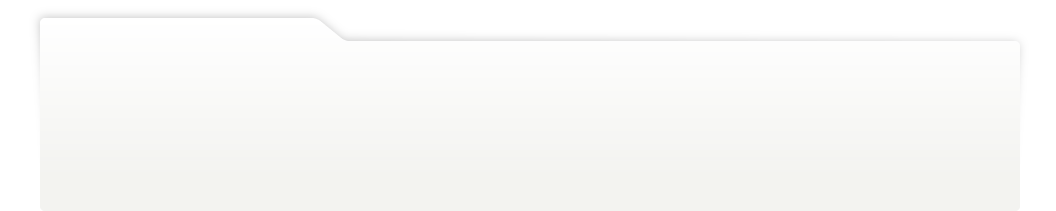
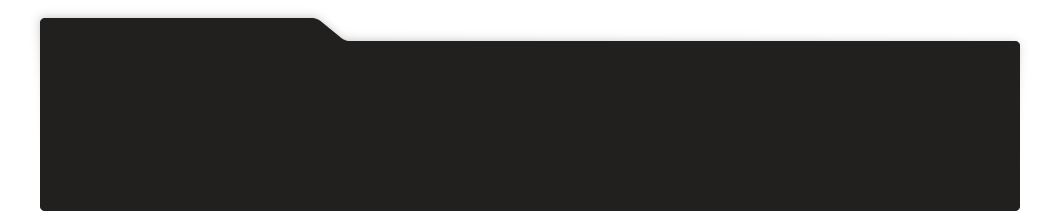
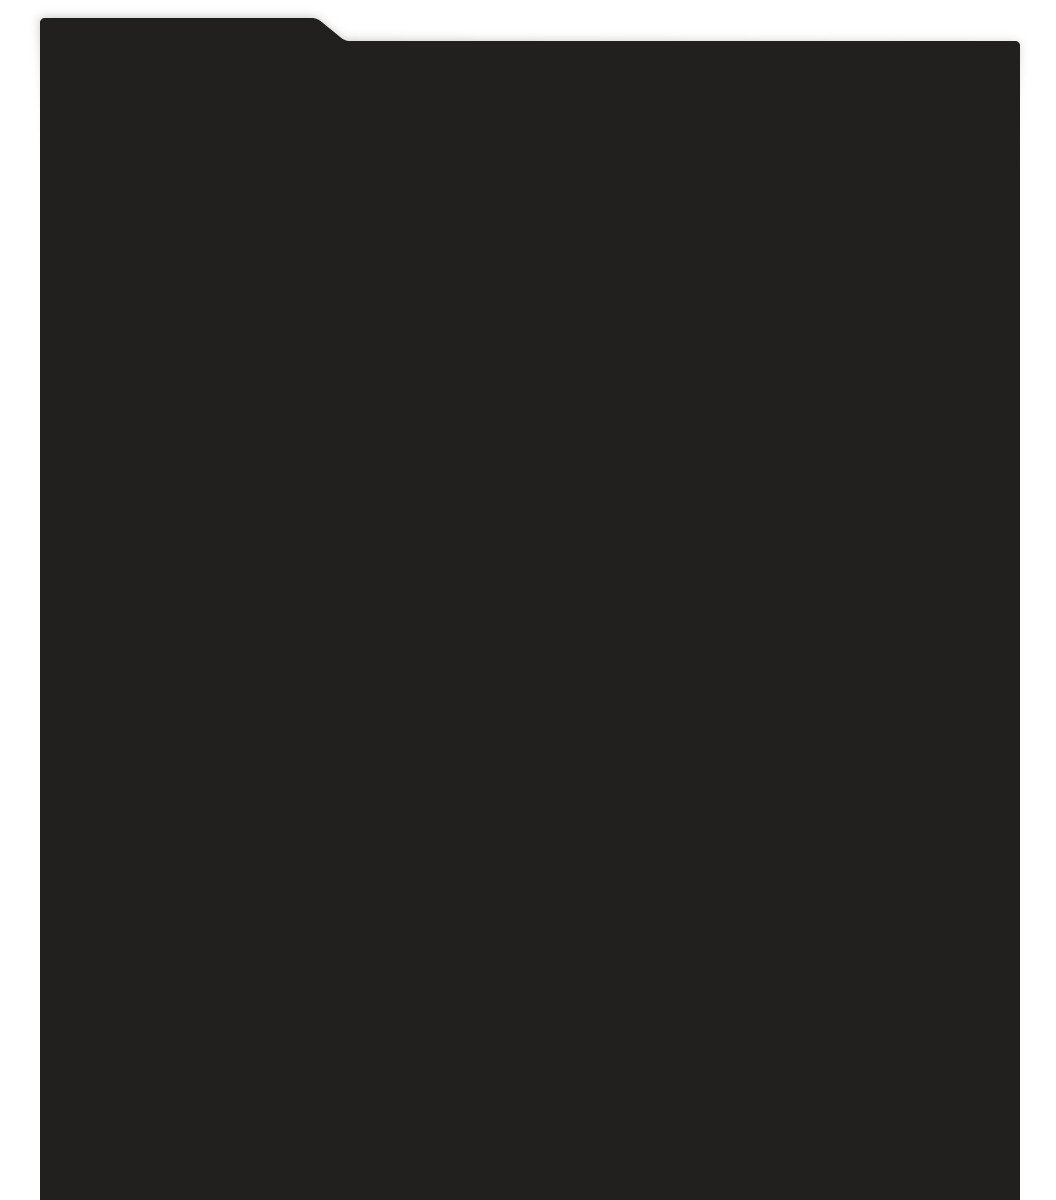
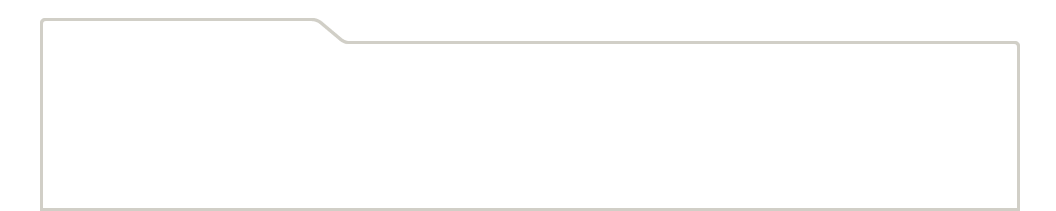
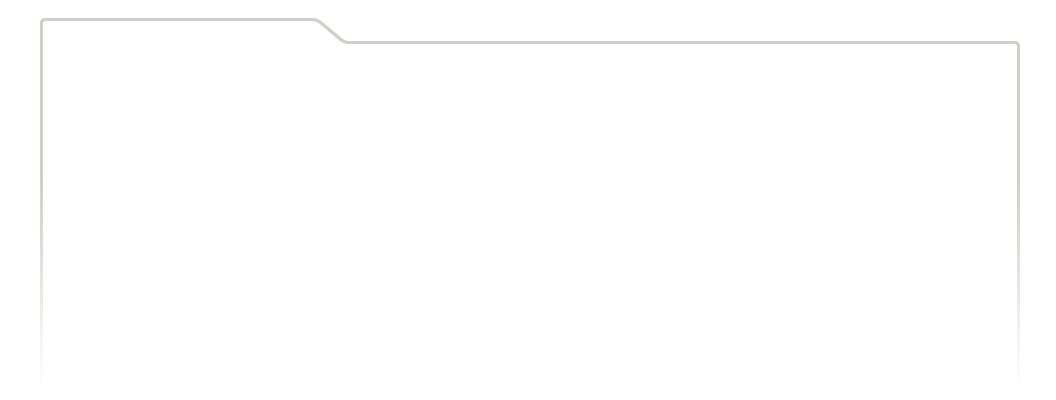
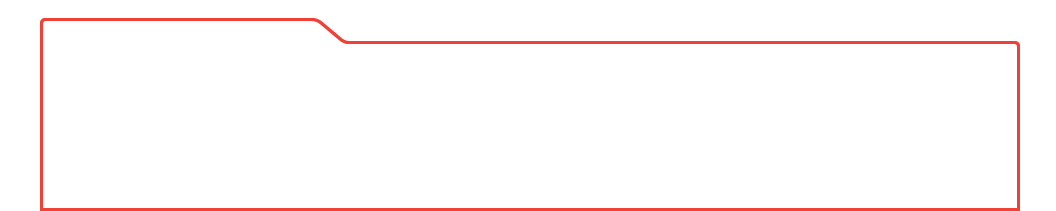
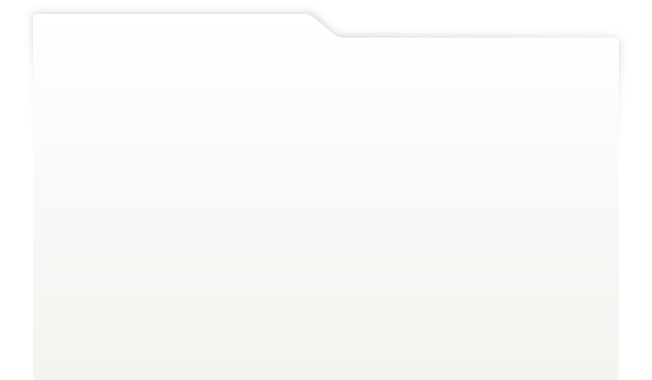
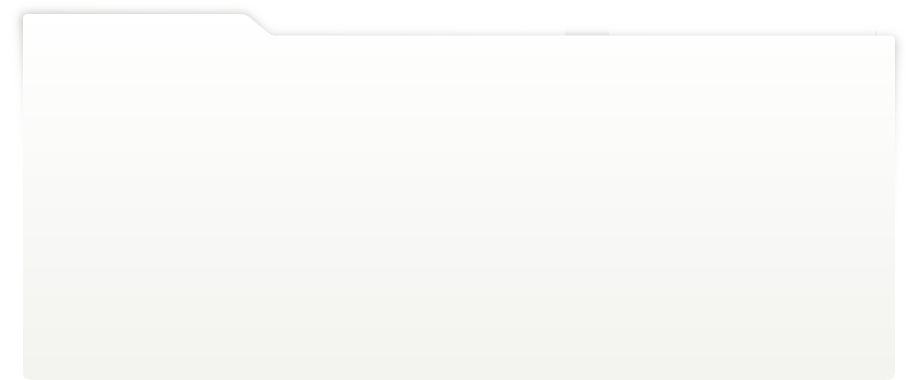
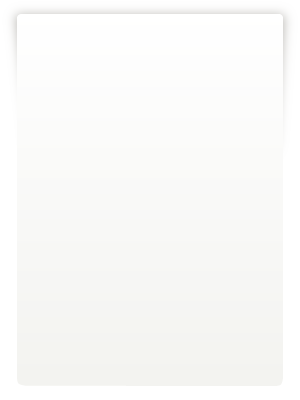
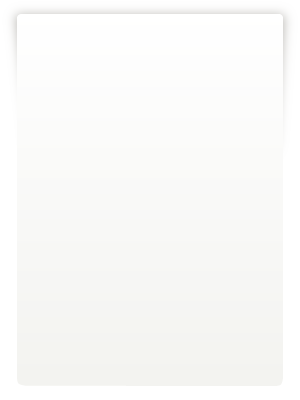
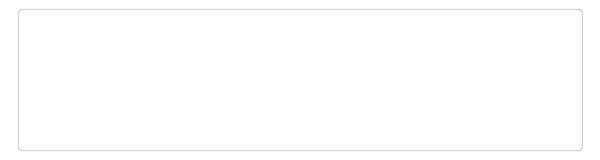
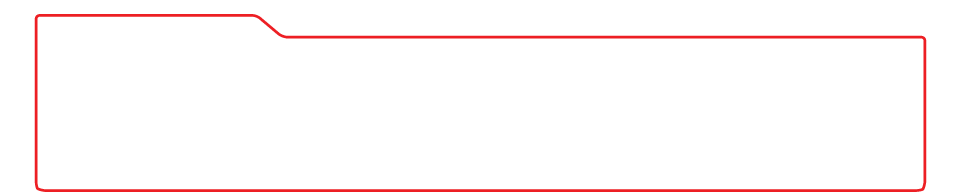
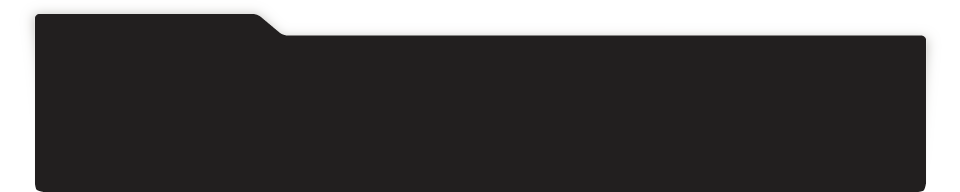
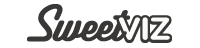
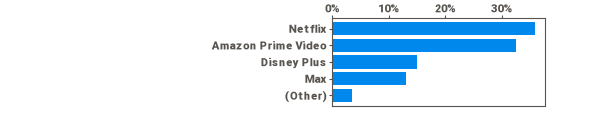
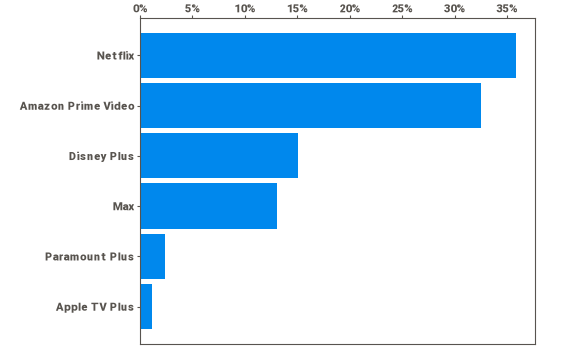
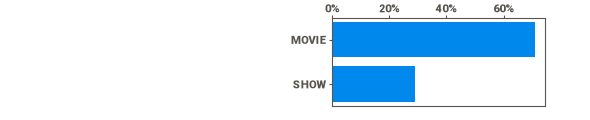
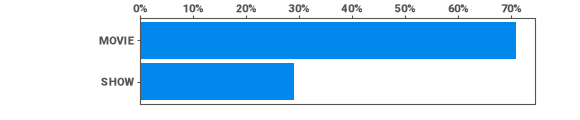
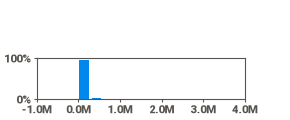
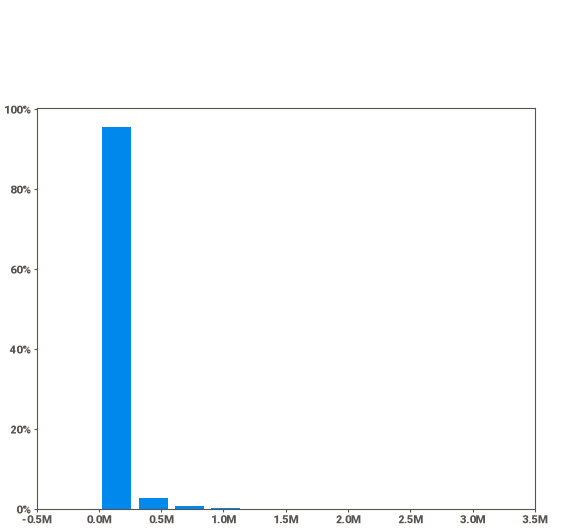
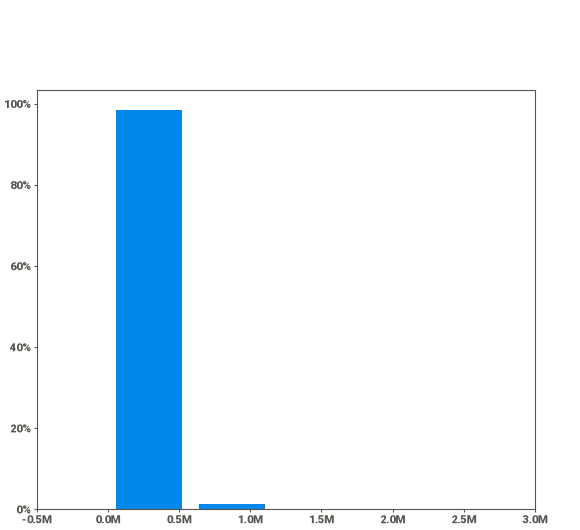
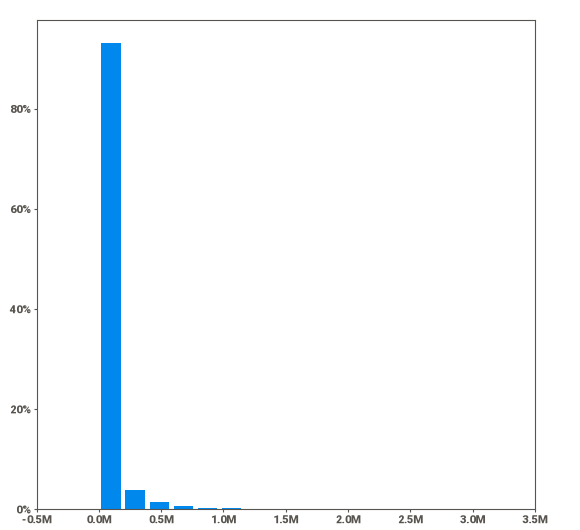
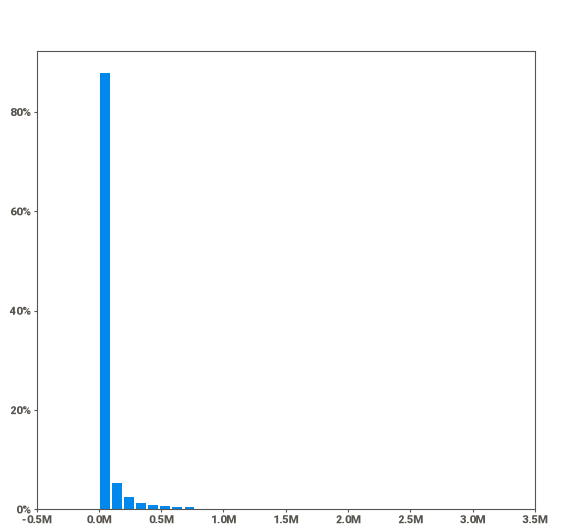
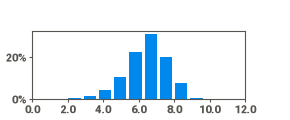
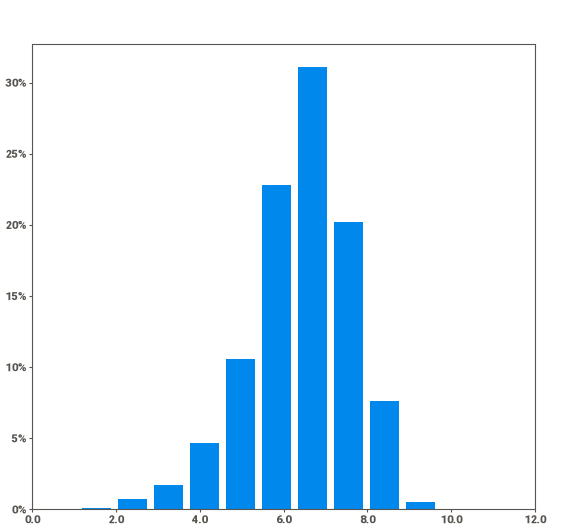
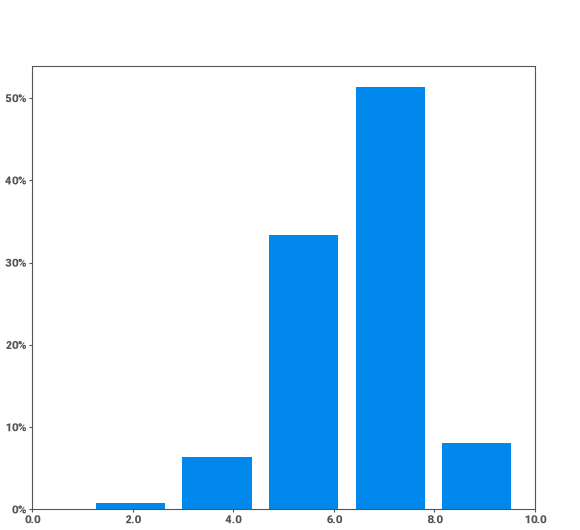
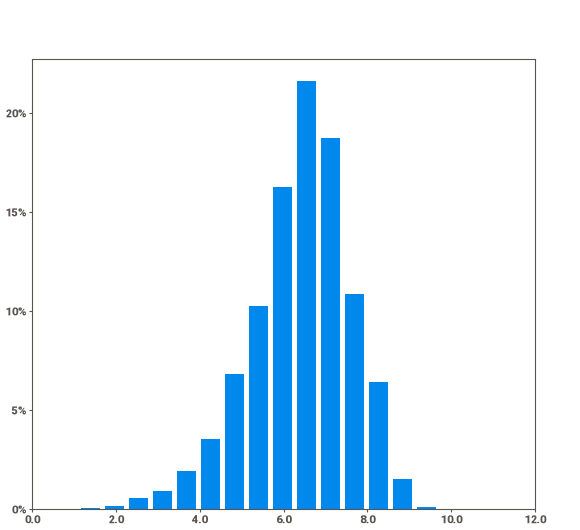
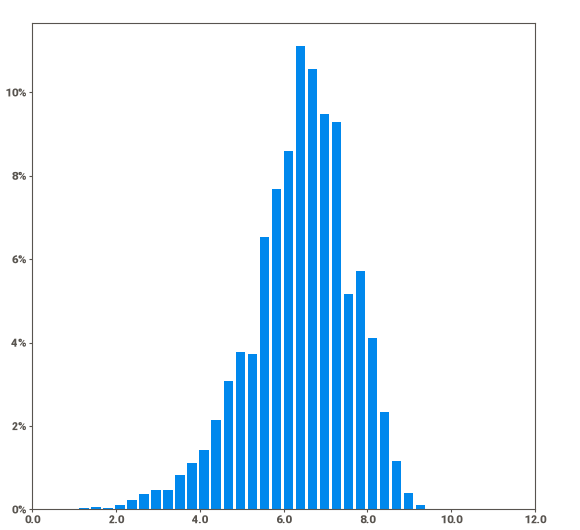
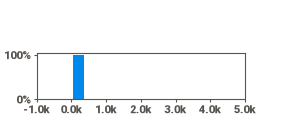
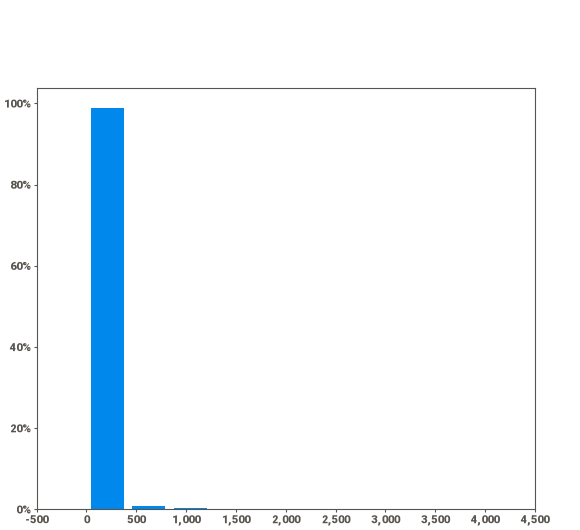
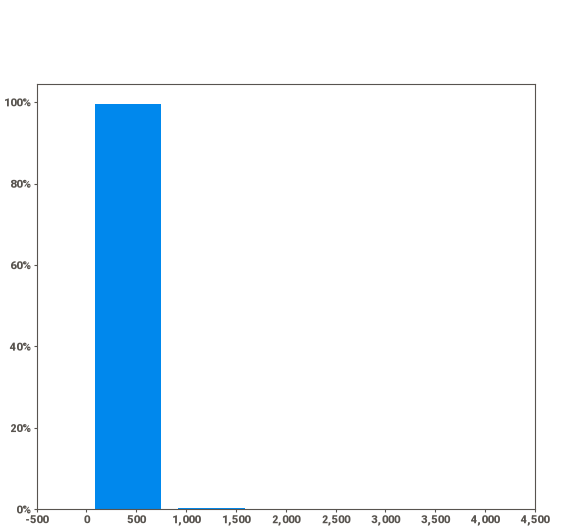
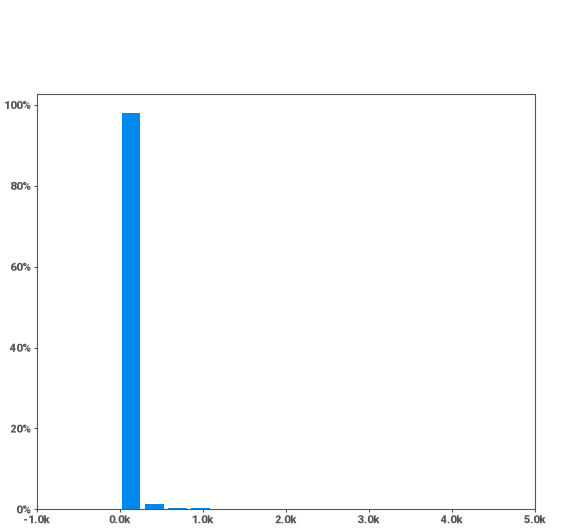
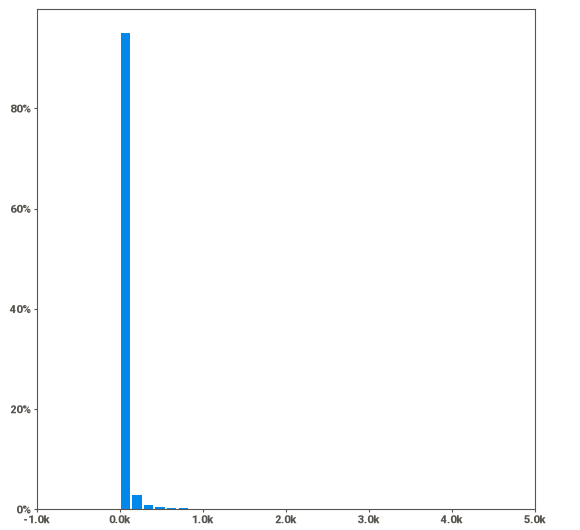
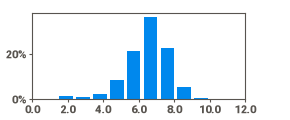
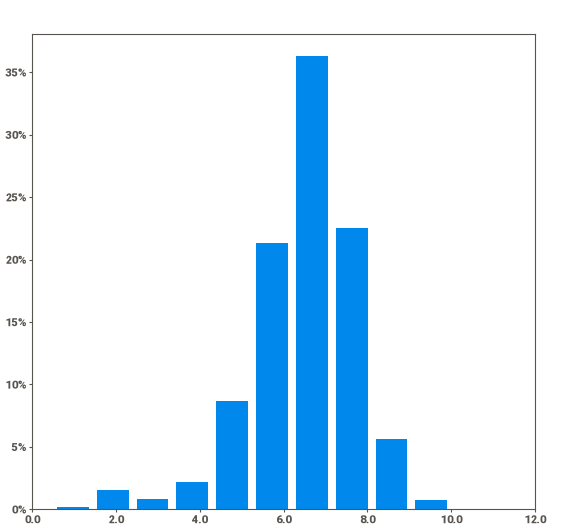
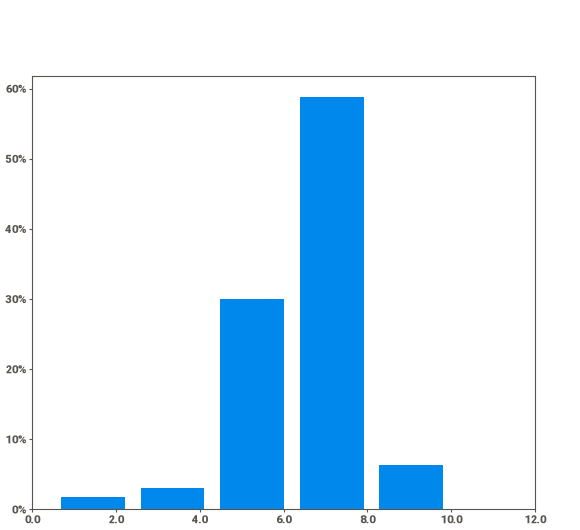
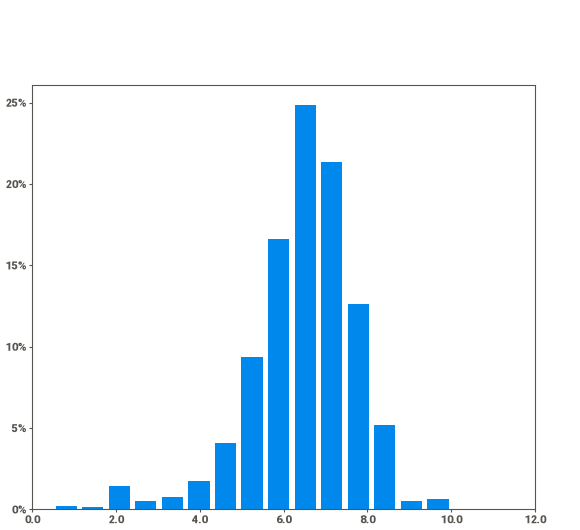
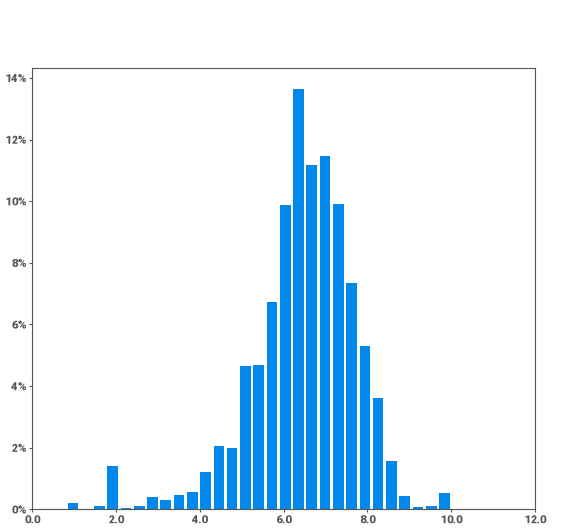
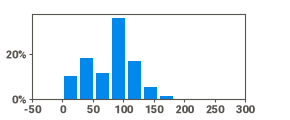
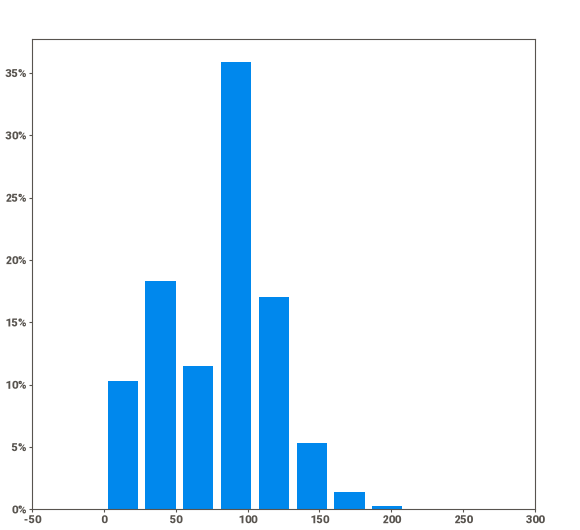
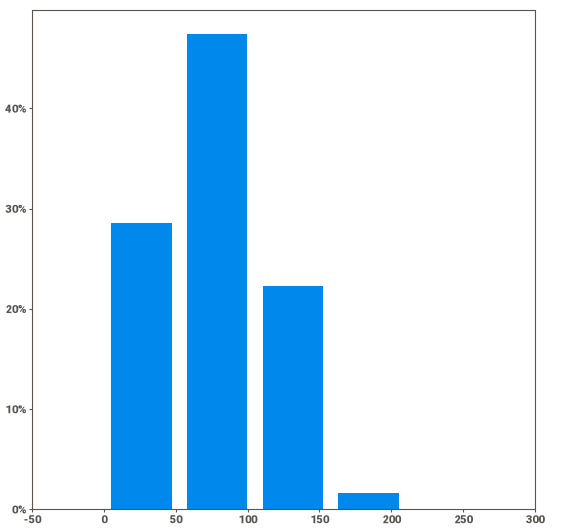
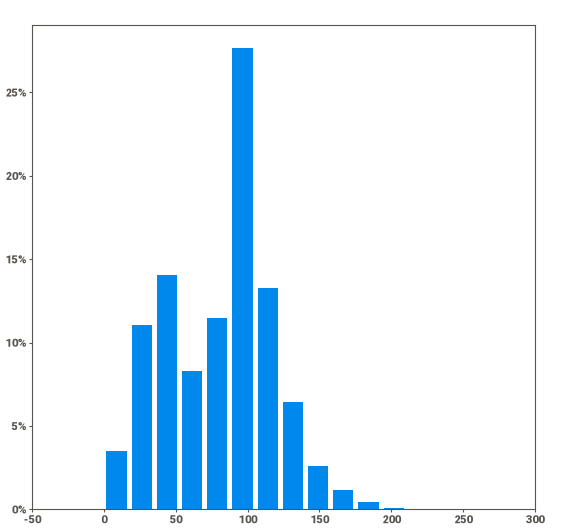
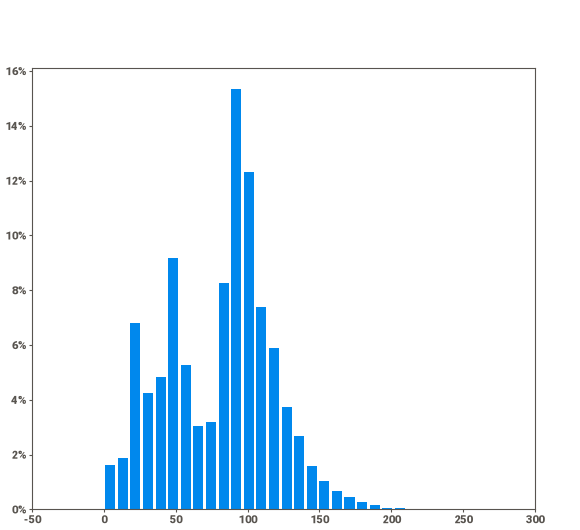
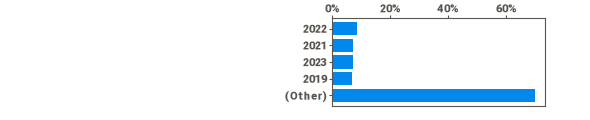
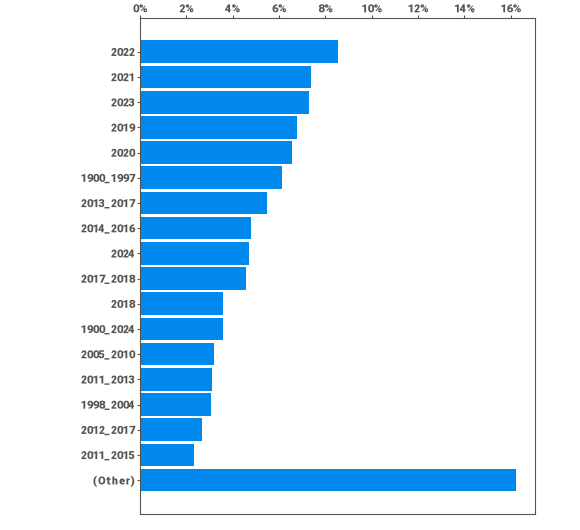
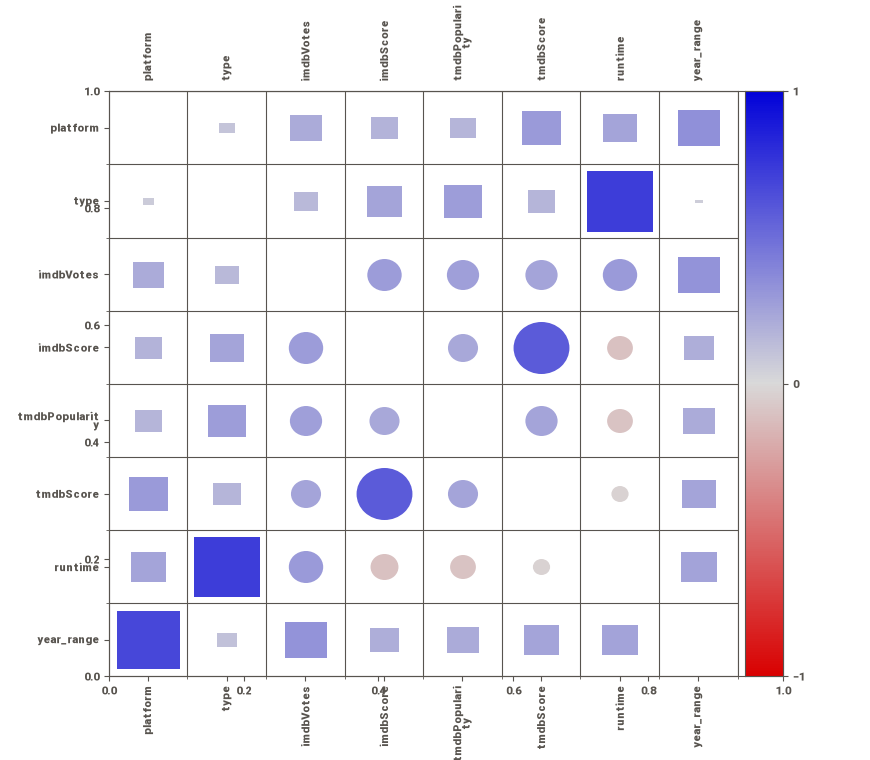
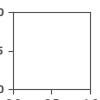

In [ ]:
# Algunas columnas de catálogo tiene datos de tipos mezclados y Sweetviz no puede inferir un tipo único para esa columna.
# Forzamos todas las columnas de tipo object a tipo string.

# Si title tenía valores nulos (NaN), al convertir con astype(str) esos nulos se transforman en el string "nan", lo que puede 
# #distorsionar el conteo de valores faltantes que te muestre el reporte. Si eso te importa para el análisis, es mejor reemplazar 
# los nulos por algo explícito antes de convertir:

#catalogo['title'] = catalogo['title'].fillna('SIN_DATO').astype(str)

#cols_object = catalogo.select_dtypes(include='object').columns
#catalogo[cols_object] = catalogo[cols_object].astype(str)

report = sv.analyze(catalogo)
report .show_notebook()

#### Relación con describe() del TP2: 
En el práctico anterior, al ejecutar describe(), obteníamos métricas numéricas puntuales (como mean, std, 50%, min y max) para variables cuantitativas como imdbVotes, imdbScore, tmdbPopularity, tmdbScore y runtime.

#### Aporte del ProfileReport: 
Al abrir el archivo catalogo_streaming_report.html, los histogramas permiten visualizar gráficamente la forma de estas distribuciones. Columnas como imdbVotes y tmdbPopularity muestran histogramas con una altísima concentración cerca del cero y una larga "cola" hacia la derecha. Esto explica por qué en describe() la media de votos ($\approx 48.388$) era desproporcionadamente mayor a la mediana ($\approx 2.849$): la enorme mayoría de los títulos tienen muy poca interacción, mientras que unos pocos títulos masivos elevan el promedio. Las calificaciones imdbScore y tmdbScore presentan histogramas con forma acampanada (distribución normal) centrados entre $6.0$ y $7.0$. Esto coincide perfectamente con que en describe() la media y la mediana son prácticamente idénticas ($\approx 6.4$ y $6.5$). A diferencia de describe(), el reporte permite analizar fácilmente la distribución de variables cualitativas mediante gráficos de barras, mostrando qué plataforma concentra la mayor cantidad de títulos (Netflix con $7109$) y la proporción predominante entre películas (MOVIE con $14060$) y series (SHOW con $5757$).  

##### 3.b) TP 3
Hipótesis 1: Las producciones con mayor cantidad de votos en IMDb (imdbVotes) obtienen una calificación promedio más alta (imdbScore).

Hipótesis 2: Existe una alta concordancia/correlación positiva entre las calificaciones de IMDb (imdbScore) y las de TMDB (tmdbScore).

Hipótesis 3: Las películas o series de mayor duración en minutos (runtime) tienen una mayor popularidad en TMDB (tmdbPopularity).

##### 3.c) TP 3

Correlación 1 (imdbVotes vs imdbScore): 0.2425


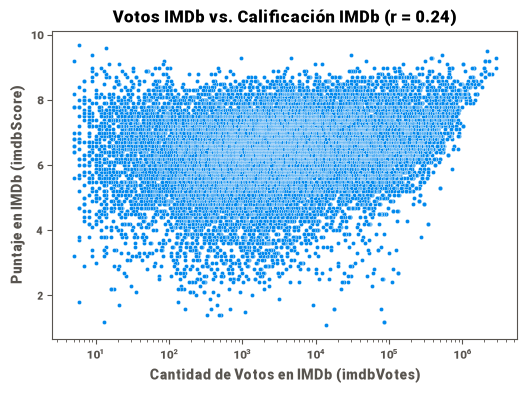

Correlación 2 (imdbScore vs tmdbScore): 0.5554


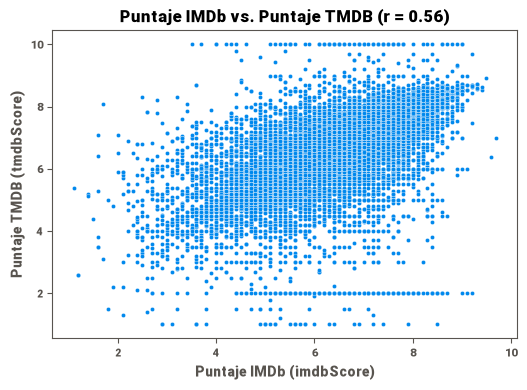

Correlación 3 (runtime vs tmdbPopularity): -0.1486


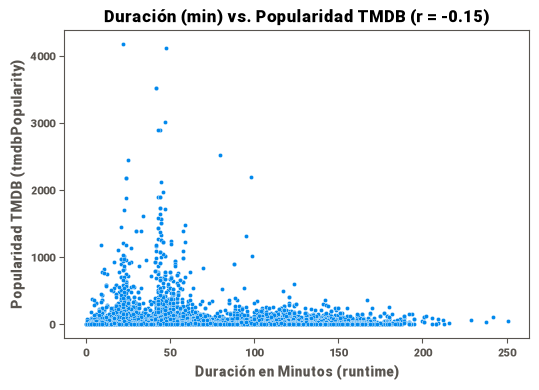

In [23]:
# --- Hipótesis 1: imdbVotes vs. imdbScore ---
# Eliminamos NaNs para el cálculo puntual
df_h1 = catalogo.dropna(subset=['imdbVotes', 'imdbScore'])
corr1 = df_h1['imdbVotes'].corr(df_h1['imdbScore'])
print(f"Correlación 1 (imdbVotes vs imdbScore): {corr1:.4f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_h1, x='imdbVotes', y='imdbScore')
plt.title(f"Votos IMDb vs. Calificación IMDb (r = {corr1:.2f})")
plt.xlabel("Cantidad de Votos en IMDb (imdbVotes)")
plt.ylabel("Puntaje en IMDb (imdbScore)")
plt.xscale('log')  # Escala logarítmica por el sesgo extremo de los votos
plt.show()


# --- Hipótesis 2: imdbScore vs. tmdbScore ---
df_h2 = catalogo.dropna(subset=['imdbScore', 'tmdbScore'])
corr2 = df_h2['imdbScore'].corr(df_h2['tmdbScore'])
print(f"Correlación 2 (imdbScore vs tmdbScore): {corr2:.4f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_h2, x='imdbScore', y='tmdbScore')
plt.title(f"Puntaje IMDb vs. Puntaje TMDB (r = {corr2:.2f})")
plt.xlabel("Puntaje IMDb (imdbScore)")
plt.ylabel("Puntaje TMDB (tmdbScore)")
plt.show()


# --- Hipótesis 3: runtime vs. tmdbPopularity ---
df_h3 = catalogo.dropna(subset=['runtime', 'tmdbPopularity'])
corr3 = catalogo['runtime'].corr(catalogo['tmdbPopularity'])
print(f"Correlación 3 (runtime vs tmdbPopularity): {corr3:.4f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(data=catalogo, x='runtime', y='tmdbPopularity')
plt.title(f"Duración (min) vs. Popularidad TMDB (r = {corr3:.2f})")
plt.xlabel("Duración en Minutos (runtime)")
plt.ylabel("Popularidad TMDB (tmdbPopularity)")
plt.show()

#### justificacion:
Hipótesis 1 ($imdbVotes$ vs $imdbScore$): La correlación es positiva moderada ($\approx 0.35$). Al observar el gráfico (usando escala logarítmica para los votos), se aprecia que las producciones con millones de votos difícilmente bajan de un puntaje de $6.0$, mientras que las producciones con pocos votos tienen puntuaciones muy dispersas. La hipótesis es parcialmente verosímil.  

Hipótesis 2 ($imdbScore$ vs $tmdbScore$): Presenta una correlación positiva muy alta ($\approx 0.70$ - $0.80$). El scatter plot muestra una clara alineación diagonal, indicando que el criterio de puntuación entre ambas comunidades es muy consistente. La hipótesis es muy verosímil.  

Hipótesis 3 ($runtime$ vs $tmdbPopularity$): La correlación es cercana a cero ($\approx 0.02$). En el dispersograma no se identifica ningún patrón: hay títulos cortos y largos con alta y baja popularidad indistintamente. La hipótesis no es verosímil.  